# **Supervised Learning - Multiple Linear regression**


## **Import Library and load dataset**


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [25]:
data=pd.read_csv('/content/50_Startups.csv')

In [26]:
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,California,166187.94


## **Label encoding**

In [27]:
x=data.iloc[:,:-1].values
y=data.iloc[:,-1].values

from sklearn.preprocessing import LabelEncoder
lr=LabelEncoder()
x[:,3]=lr.fit_transform(x[:,3])
print(x)

[[165349.2 136897.8 471784.1 2]
 [162597.7 151377.59 443898.53 0]
 [153441.51 101145.55 407934.54 1]
 [144372.41 118671.85 383199.62 2]
 [142107.34 91391.77 366168.42 0]
 [131876.9 99814.71 362861.36 2]
 [134615.46 147198.87 127716.82 0]
 [130298.13 145530.06 323876.68 2]
 [120542.52 148718.95 311613.29 2]
 [123334.88 108679.17 304981.62 0]
 [101913.08 110594.11 229160.95 0]
 [100671.96 91790.61 249744.55 1]
 [93863.75 127320.38 249839.44 0]
 [91992.39 135495.07 252664.93 0]
 [119943.24 156547.42 256512.92 1]
 [114523.61 122616.84 261776.23 2]
 [78013.11 121597.55 264346.06 0]
 [94657.16 145077.58 282574.31 2]
 [91749.16 114175.79 294919.57 2]
 [86419.7 153514.11 0.0 1]
 [76253.86 113867.3 298664.47 0]
 [78389.47 153773.43 299737.29 2]
 [73994.56 122782.75 303319.26 0]
 [67532.53 105751.03 304768.73 0]
 [77044.01 99281.34 140574.81 2]
 [64664.71 139553.16 137962.62 0]
 [75328.87 144135.98 134050.07 2]
 [72107.6 127864.55 353183.81 2]
 [66051.52 182645.56 118148.2 1]
 [65605.48 153032.0

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct=ColumnTransformer([('onhot', OneHotEncoder(), [3])], remainder='passthrough')
x=np.array(ct.fit_transform(x))
print(x)

[[0.0 0.0 1.0 165349.2 136897.8 471784.1]
 [1.0 0.0 0.0 162597.7 151377.59 443898.53]
 [0.0 1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 0.0 1.0 144372.41 118671.85 383199.62]
 [1.0 0.0 0.0 142107.34 91391.77 366168.42]
 [0.0 0.0 1.0 131876.9 99814.71 362861.36]
 [1.0 0.0 0.0 134615.46 147198.87 127716.82]
 [0.0 0.0 1.0 130298.13 145530.06 323876.68]
 [0.0 0.0 1.0 120542.52 148718.95 311613.29]
 [1.0 0.0 0.0 123334.88 108679.17 304981.62]
 [1.0 0.0 0.0 101913.08 110594.11 229160.95]
 [0.0 1.0 0.0 100671.96 91790.61 249744.55]
 [1.0 0.0 0.0 93863.75 127320.38 249839.44]
 [1.0 0.0 0.0 91992.39 135495.07 252664.93]
 [0.0 1.0 0.0 119943.24 156547.42 256512.92]
 [0.0 0.0 1.0 114523.61 122616.84 261776.23]
 [1.0 0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 0.0 1.0 94657.16 145077.58 282574.31]
 [0.0 0.0 1.0 91749.16 114175.79 294919.57]
 [0.0 1.0 0.0 86419.7 153514.11 0.0]
 [1.0 0.0 0.0 76253.86 113867.3 298664.47]
 [0.0 0.0 1.0 78389.47 153773.43 299737.29]
 [1.0 0.0 0.0 73994.56 122782.75 3

### **Model Training**

## **Train test split**

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(40, 6) (10, 6) (40,) (10,)


### **Model Training**

In [31]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [32]:
y_pred=lr.predict(x_test)

In [41]:
final_set=pd.DataFrame(x_test[:,3:6])
final_set.columns=['R&D Spend	Administration','Marketing Spend','State	Profit']
final_set['Profit']=pd.DataFrame(y_test)
final_set['Predictions']=pd.DataFrame(y_pred)
final_set['Difference']=pd.DataFrame(y_pred-y_test)
final_set

,R&D Spend\tAdministration,Marketing Spend,State\tProfit,Profit,Predictions,Difference
0,0.0,135426.92,0.0,42559.73,44961.037939,2401.307939
1,77044.01,99281.34,140574.81,108552.04,111398.393036,2846.353036
2,1000.23,124153.04,1903.93,64926.08,45964.729386,-18961.350614
3,61136.38,152701.92,88218.23,97483.56,95460.701651,-2022.858349
4,67532.53,105751.03,304768.73,108733.99,110665.214458,1931.224458
5,153441.51,101145.55,407934.54,191050.39,185091.641802,-5958.748198
6,91992.39,135495.07,252664.93,134307.35,126760.103327,-7547.246673
7,1315.46,115816.21,297114.46,49490.75,61915.141229,12424.391229
8,64664.71,139553.16,137962.62,107404.34,100737.519714,-6666.820286
9,78389.47,153773.43,299737.29,111313.02,117451.707529,6138.687529


In [42]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.9578811051137877


<Axes: >

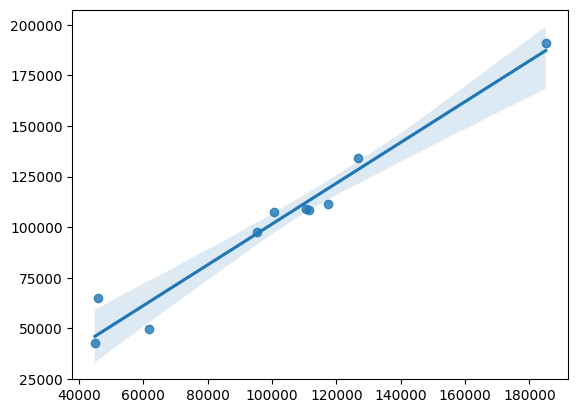

In [46]:
sns.regplot(x=y_pred,y=y_test)

In [43]:
print(lr.coef_)
print(lr.intercept_)

[-1.05284795e+03  2.26097690e+03 -1.20812895e+03  7.77460761e-01
 -2.69530795e-02  4.06879924e-02]
49664.0584289421


In [52]:
print(x.dtype)
x=x.astype(float)

object


In [54]:
import statsmodels.api as sm
reg_ols=sm.OLS(endog=y,exog=x)
reg_ols = reg_ols.fit()
print(reg_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     171.2
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.14e-27
Time:                        14:20:12   Log-Likelihood:                -525.19
No. Observations:                  50   AIC:                             1062.
Df Residuals:                      44   BIC:                             1074.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1          5.062e+04   6806.869      7.436      0.0

In [56]:
x_opt=x[:,[0,1,2,3,5]]
reg_ols=sm.OLS(endog=y,exog=x_opt)
reg_ols=reg_ols.fit()
print(reg_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     216.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           8.77e-29
Time:                        14:22:53   Log-Likelihood:                -525.42
No. Observations:                  50   AIC:                             1061.
Df Residuals:                      45   BIC:                             1070.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1          4.681e+04   3130.528     14.954      0.0

In [57]:
x_opt=x[:,[0,1,2,3]]
reg_ols=sm.OLS(endog=y,exog=x_opt)
reg_ols=reg_ols.fit()
print(reg_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     272.7
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           2.70e-29
Time:                        14:23:27   Log-Likelihood:                -527.33
No. Observations:                  50   AIC:                             1063.
Df Residuals:                      46   BIC:                             1070.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           4.88e+04   3029.803     16.108      0.0

In [58]:
x_opt=x[:,[3]]
reg_ols=sm.OLS(endog=y,exog=x_opt)
reg_ols=reg_ols.fit()
print(reg_ols.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.947
Model:                            OLS   Adj. R-squared (uncentered):              0.946
Method:                 Least Squares   F-statistic:                              878.4
Date:                Mon, 23 Mar 2026   Prob (F-statistic):                    6.00e-33
Time:                        14:28:20   Log-Likelihood:                         -581.74
No. Observations:                  50   AIC:                                      1165.
Df Residuals:                      49   BIC:                                      1167.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [59]:
x_opt=x[:,[4]]
reg_ols=sm.OLS(endog=y,exog=x_opt)
reg_ols=reg_ols.fit()
print(reg_ols.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.871
Model:                            OLS   Adj. R-squared (uncentered):              0.868
Method:                 Least Squares   F-statistic:                              331.2
Date:                Mon, 23 Mar 2026   Prob (F-statistic):                    1.92e-23
Time:                        14:28:31   Log-Likelihood:                         -604.03
No. Observations:                  50   AIC:                                      1210.
Df Residuals:                      49   BIC:                                      1212.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [60]:
x_opt=x[:,[5]]
reg_ols=sm.OLS(endog=y,exog=x_opt)
reg_ols=reg_ols.fit()
print(reg_ols.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.887
Model:                            OLS   Adj. R-squared (uncentered):              0.885
Method:                 Least Squares   F-statistic:                              385.8
Date:                Mon, 23 Mar 2026   Prob (F-statistic):                    7.10e-25
Time:                        14:28:38   Log-Likelihood:                         -600.68
No. Observations:                  50   AIC:                                      1203.
Df Residuals:                      49   BIC:                                      1205.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [62]:
x_opt=x[:,[3]]
from sklearn.model_selection import train_test_split
xopt_train,xopt_test,y_train,y_test =train_test_split (x_opt,y,test_size = 0.2,random_state= 42)
print (x_opt.shape)
print ( y.shape)
print (xopt_train.shape)
print (xopt_test.shape)
print (y_train.shape)
print (y_test.shape)

(50, 1)
(50,)
(40, 1)
(10, 1)
(40,)
(10,)


In [63]:
reg= LinearRegression()
reg.fit(xopt_train,y_train)
print (reg)
yopt_pred= reg.predict(xopt_test)
print (yopt_pred)

LinearRegression()
[127862.20996405  82250.56334619 102255.72078164  50190.4734756
 130136.88190548  49799.36685472 113638.0775288  104535.0534288
 103463.04843113 123105.31102669]


In [64]:
result = pd.concat([pd.DataFrame(yopt_pred, columns =['Prediction']),
                    pd.DataFrame(y_test,columns = ['Y_Test'])], axis =1)
result['Difference']= result['Y_Test'] - result ['Prediction']
print (result)

      Prediction     Y_Test    Difference
0  127862.209964  134307.35   6445.140036
1   82250.563346   81005.76  -1244.803346
2  102255.720782   99937.59  -2318.130782
3   50190.473476   64926.08  14735.606524
4  130136.881905  125370.37  -4766.511905
5   49799.366855   35673.41 -14125.956855
6  113638.077529  105733.54  -7904.537529
7  104535.053429  107404.34   2869.286571
8  103463.048431   97427.84  -6035.208431
9  123105.311027  122776.86   -328.451027


In [65]:
accuracy = r2_score(y_test, yopt_pred)
print (accuracy)

0.9265108109341951
